In [1]:
# Imports
import polars as pl
pl.Config.set_fmt_str_lengths(100)
import glob
import os

#Python Imports
import random
import os

# External packages
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.api import VAR
import sklearn.feature_selection
from sklearn.feature_selection import mutual_info_regression
import statsmodels.api as sm
from scipy import signal
from scipy import stats
from statsmodels.tsa.stattools import grangercausalitytests
import numpy as np
import mne
import pickle
import concurrent.futures


/Users/arias/opt/anaconda3/envs/stim39/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


# Facial mimicry AU12

In [21]:
check_df = pl.read_csv("../data/face_data/pyf_results/all_au_pf.csv"
                          , columns=["user_id", "other_id", "participant_condition", "other_condition", "manipulated", "AU12"]
                          ).to_pandas()

In [22]:
print("Number of participants : " +str(len(np.unique(check_df["user_id"].values))))

print("Number of other_id participants : " + str(len(np.unique(check_df["other_id"].dropna().values))))


Number of participants : 77
Number of other_id participants : 60


In [23]:
smile_df = pl.read_csv("../data/face_data/pyf_results/all_au_pf.csv"
                          , columns=["sid", "user_id", "other_id", "participant_condition", "other_condition", "manipulated", "AU12"]
                          )

smile_df.head()
#Average smile measures
#smile_df = smile_df.with_columns(
#    smile = smile_df["mouthSmileRight"] + smile_df["mouthSmileLeft"]
#    )

AU12,sid,manipulated,user_id,other_id,participant_condition,other_condition
f64,str,bool,str,str,str,str
0.152352,"""mkprolific_participant_real_31""",false,"""mkprolific_participant_real_31p5""","""mkprolific_participant_real_31p4""","""U""","""S"""
0.215805,"""mkprolific_participant_real_31""",false,"""mkprolific_participant_real_31p5""","""mkprolific_participant_real_31p4""","""U""","""S"""
0.2201421,"""mkprolific_participant_real_31""",false,"""mkprolific_participant_real_31p5""","""mkprolific_participant_real_31p4""","""U""","""S"""
0.243679,"""mkprolific_participant_real_31""",false,"""mkprolific_participant_real_31p5""","""mkprolific_participant_real_31p4""","""U""","""S"""
0.229239,"""mkprolific_participant_real_31""",false,"""mkprolific_participant_real_31p5""","""mkprolific_participant_real_31p4""","""U""","""S"""


/Users/arias/opt/anaconda3/envs/stim39/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/arias/opt/anaconda3/envs/stim39/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


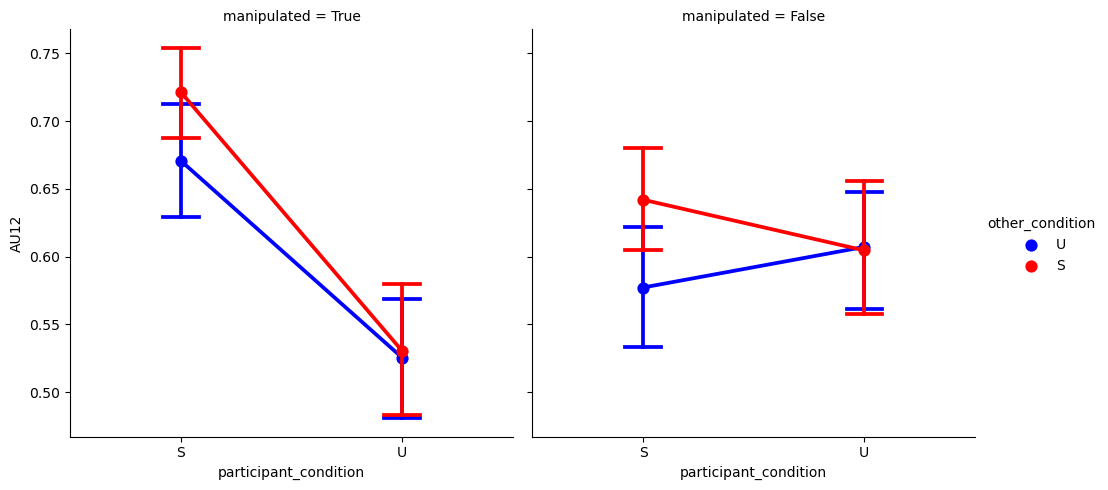

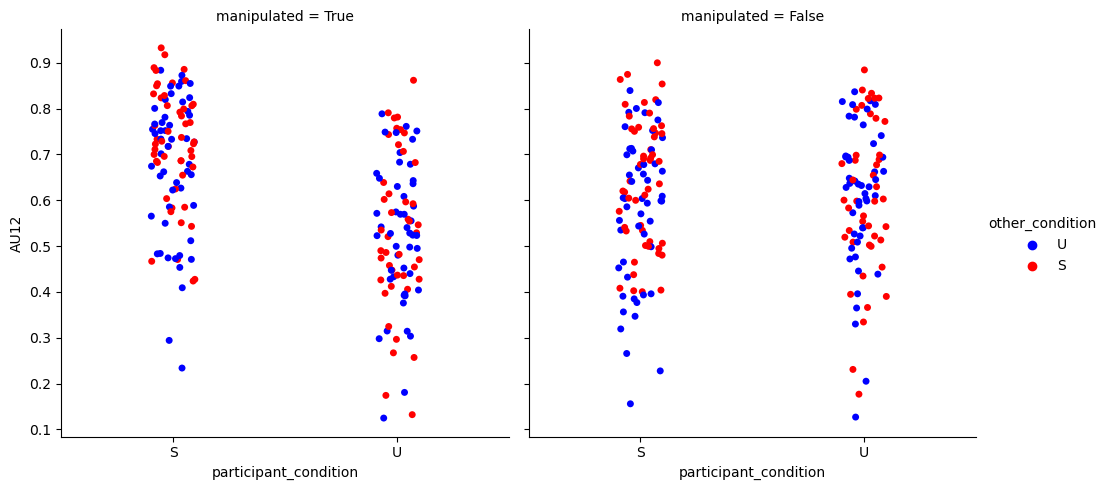

In [24]:
import seaborn as sns

smile_df = smile_df.to_pandas()
smile_df = smile_df.groupby(["sid", "user_id", "other_id", "participant_condition", "other_condition", "manipulated"]).mean(numeric_only=True).reset_index()


sns.catplot(x= "participant_condition"
            , y="AU12"
            , hue="other_condition"
            , col="manipulated"
            , data=smile_df
            , kind="point"
            , palette=sns.color_palette(['blue', 'red'])
            , col_order=[True, False]
            , order=["S", "U"]
            , capsize=.16

            )

sns.catplot(x= "participant_condition"
            , y="AU12"
            , hue="other_condition"
            , col="manipulated"
            , data=smile_df
            , palette=sns.color_palette(['blue', 'red'])
            , col_order=[True, False]
            , order=["S", "U"]
            )



/Users/arias/opt/anaconda3/envs/stim39/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/arias/opt/anaconda3/envs/stim39/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


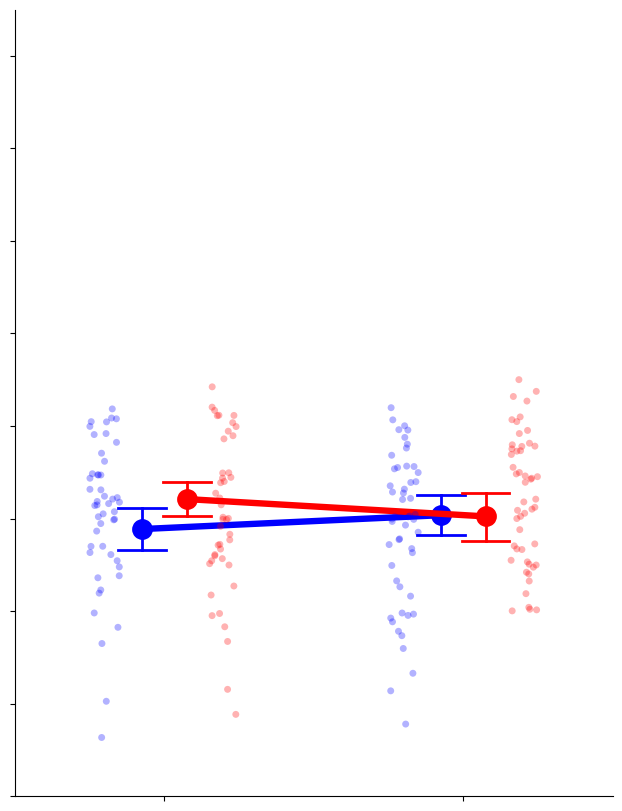

In [25]:
df_analysis = smile_df.loc[smile_df["manipulated"] == False]


g = sns.catplot( x="participant_condition", y="AU12", units="user_id"
                    , height=8.6
                    , aspect=0.8
                    , data=df_analysis
                    , kind="point"
                    , capsize=.16
                    , hue="other_condition"
                    , legend=False
                    , scale=1.7
                    , dodge= 0.15
                    , errwidth=2
                    , order=["S", "U"]
                    , palette= sns.color_palette(["blue", "red"])
            )

# Add individual measure points
sns.stripplot(x="participant_condition", y="AU12"
                , data=df_analysis
                , hue="other_condition", dodge=0.15, size=5, alpha=0.3
                , palette=["blue", "red"]
                , legend=False
                )    
    
g.set(ylim=(0, 1.7))

plt.savefig("plots/pf_facial_mimicry_legend.pdf", bbox_inches='tight')
g.set(xticklabels=[], yticklabels=[], title='',xlabel=None, ylabel=None)
plt.savefig("plots/pf_facial_mimicry.pdf", bbox_inches='tight')

In [27]:
smile_df.to_csv("../data/face_data/pyf_results/smile.csv")

# Propagation to AU06 

In [13]:
smile_df = pl.read_csv("../data/face_data/pyf_results/all_au_pf.csv"
                          , columns=["sid", "user_id", "other_id", "participant_condition", "other_condition", "manipulated", "AU06"]
                          ).to_pandas()

smile_df.head()

,AU06,sid,manipulated,user_id,other_id,participant_condition,other_condition
0,0.423244,mkprolific_participant_real_31,False,mkprolific_participant_real_31p5,mkprolific_participant_real_31p4,U,S
1,0.430598,mkprolific_participant_real_31,False,mkprolific_participant_real_31p5,mkprolific_participant_real_31p4,U,S
2,0.446143,mkprolific_participant_real_31,False,mkprolific_participant_real_31p5,mkprolific_participant_real_31p4,U,S
3,0.446935,mkprolific_participant_real_31,False,mkprolific_participant_real_31p5,mkprolific_participant_real_31p4,U,S
4,0.446474,mkprolific_participant_real_31,False,mkprolific_participant_real_31p5,mkprolific_participant_real_31p4,U,S


/Users/arias/opt/anaconda3/envs/stim39/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/arias/opt/anaconda3/envs/stim39/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


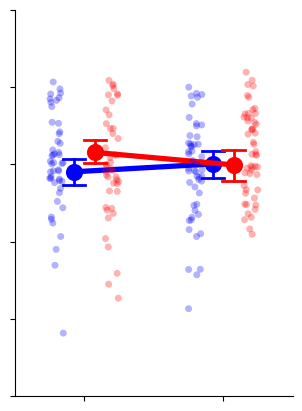

In [16]:
smile_df = smile_df.groupby(["sid", "user_id", "other_id", "participant_condition", "other_condition", "manipulated"]).mean(numeric_only=True).reset_index()

df_analysis = smile_df.loc[smile_df["manipulated"] == False]


g = sns.catplot( x="participant_condition", y="AU06", units="user_id"
                    , height=4.6
                    , aspect=0.8
                    , data=df_analysis
                    , kind="point"
                    , capsize=.16
                    , hue="other_condition"
                    , legend=False
                    , scale=1.4
                    , dodge= 0.15
                    , errwidth=2
                    , order=["S", "U"]
                    , palette= sns.color_palette(["blue", "red"])
            )

# Add individual measure points
sns.stripplot(x="participant_condition", y="AU06"
                , data=df_analysis
                , hue="other_condition", dodge=0.15, size=5, alpha=0.3
                , palette=["blue", "red"]
                , legend=False
                )    
    
g.set(ylim=(0, 1))

plt.savefig("plots/pf_facial_mimicry_AU06_legend.pdf", bbox_inches='tight')
g.set(xticklabels=[], yticklabels=[], title='',xlabel=None, ylabel=None)
plt.savefig("plots/pf_facial_mimicry_AU06.pdf", bbox_inches='tight')

In [28]:
smile_df.to_csv("../data/face_data/pyf_results/au06.csv")

# Synchrony

In [18]:
#Import data
smile_df = pl.read_csv("../data/face_data/pyf_results/all_au_pf.csv"
                          , columns=["sid", "user_id", "other_id", "dyad", "recording_nb", "participant_condition", "other_condition", "manipulated"
                                     , "happiness", "frame" ]
                        )

#Prepare data for merge
#smile_df = smile_df.with_columns(
#    smile = smile_df["mouthSmileRight"] + smile_df["mouthSmileLeft"]
#    )

#preapre data
idx= ["sid", "user_id", "other_id", "participant_condition", "other_condition", "manipulated", "dyad", "recording_nb", "frame"]
au_df = smile_df.groupby(idx).mean().sort(idx).to_pandas()
au_df.head()

/var/folders/g5/mqbcmmn575z0s3c021r942c80000gp/T/ipykernel_73116/2308227261.py:14: DeprecationWarning: `groupby` is deprecated. It has been renamed to `group_by`.
  au_df = smile_df.groupby(idx).mean().sort(idx).to_pandas()


,sid,user_id,other_id,participant_condition,other_condition,manipulated,dyad,recording_nb,frame,happiness
0,mkprolific_participant_real_21,mkprolific_participant_real_21p1,mkprolific_participant_real_21p5,U,U,False,p1p5,1,0,0.003107
1,mkprolific_participant_real_21,mkprolific_participant_real_21p1,mkprolific_participant_real_21p5,U,U,False,p1p5,1,1,0.005633
2,mkprolific_participant_real_21,mkprolific_participant_real_21p1,mkprolific_participant_real_21p5,U,U,False,p1p5,1,2,0.003502
3,mkprolific_participant_real_21,mkprolific_participant_real_21p1,mkprolific_participant_real_21p5,U,U,False,p1p5,1,3,0.004159
4,mkprolific_participant_real_21,mkprolific_participant_real_21p1,mkprolific_participant_real_21p5,U,U,False,p1p5,1,4,0.002486


In [19]:
#define global features
other_manipulations = [True, False]
source_features = ["happiness"]
target_features = ["happiness"]

In [20]:
#Check which interactions were recorded correctly and can be used for this analysis:
correct_interactions   = []
incorrect_interactions = []
for interaction in glob.glob("data/preproc/prolific/*/trimed/*"):
    recordings = glob.glob(interaction + "/*.mp4")
    if len(recordings)==4:
        sid = interaction.split("/")[3]
        dyad = interaction.split("/")[5][2:]

        correct_interactions.append((sid, dyad))
    else:
        incorrect_interactions.append((sid, dyad))

print("Found "+ str(len(correct_interactions)) + " correct interactions")
print("Found "+ str(len(incorrect_interactions)) + " incorrect interactions")

Found 0 correct interactions
Found 0 incorrect interactions


In [58]:
#Both manipulated with the same value
lag = 750 # 10 seconds before and 10 seconds after
nb_min_samples = 1800 #atleast 1 minute per interaction

mi_df = pd.DataFrame()
df_lags = pd.DataFrame()
for other_manipulated in other_manipulations:
    for (sid, participant_manipulated, dyad, user_id), dyad_df in au_df.groupby(["sid", "manipulated", "dyad", "user_id"]):
        
        #if participant_manipulated == True:
        #    continue
        
        #Check if interaction was recorded correctly (4 recordings in total).
        found=False
        for interaction in correct_interactions:
            if sid == interaction[0] and dyad == interaction[1]:
                found = True
                break
        if not found:
            #print("Skipping not correct recording - dyad : " + dyad + " sid : " + sid)
            continue
            
        #Prepare participants' time series
        participant_df = dyad_df.loc[dyad_df["user_id"] == user_id]
        participant_df = participant_df.ffill(axis="rows")
        participant_df = participant_df.bfill(axis="rows")
        
        other_id = participant_df["other_id"]
        nulls = np.unique(other_id.isnull())
        if len(nulls)==1 and nulls[0]:
            continue

        other_id = np.unique(other_id)[0]    
        partner_df = au_df.loc[au_df["user_id"] == other_id]
        partner_df = partner_df.loc[partner_df["dyad"] == dyad]    
        partner_df = partner_df.loc[partner_df["manipulated"] == other_manipulated]        
        partner_df = partner_df.ffill(axis="rows")
        partner_df = partner_df.bfill(axis="rows")
        if not len(partner_df)>0:
            continue


        for source_feature in source_features:
            for target_feature in target_features:    

                #preapre participant time series
                X = participant_df[source_feature].values

                #preapre target time series
                y = partner_df[target_feature].values

                if len(y)==0 or len(X) ==0 or len(y)< nb_min_samples or len(X)< nb_min_samples:
                    continue

                #Keep only the same number of samples for both
                max = np.min([len(X), len(y)])
                X = X[0:max]
                y = y[0:max]

                #cross-correlation
                corr_X = [(val-np.nanmean(X))/np.nanstd(X) for val in X]
                corr_y = [(val-np.nanmean(y))/np.nanstd(y) for val in y]
                corr = signal.correlate(corr_X, corr_y, mode='same') 
                corr = corr  / len(X)

                #Select only cross correaltion between +/- lag
                selected_corr = corr[round(len(corr)/2 - lag): round(len(corr)/2 + lag)]
                pears_r, p = stats.pearsonr(corr_X, corr_y)
                max_corr = np.arctanh(np.nanmax(selected_corr))

                #Compute MI
                X = X.reshape(-1,1)    
                mi = mutual_info_regression(X=X, y=y
                                   , discrete_features = 'auto'
                                   , n_neighbors = 60
                                   , copy = True
                                   , random_state=None
                               )

                #Save results to a DataFrame
                aux_df = pd.DataFrame()
                aux_df["source_feature"]           = [source_feature]
                aux_df["target_feature"]           = [target_feature]
                aux_df["other_id"]                 = [other_id]
                aux_df["user_id"]                  = [user_id]
                aux_df["participant_manipulated"]  = [participant_manipulated]
                aux_df["other_manipulated"]        = [other_manipulated]
                aux_df["dyad"]                     = [dyad]
                aux_df["sid"]                      = [sid]
                aux_df["mi"]                       = mi
                aux_df["max_corr"]                 = [max_corr]

                aux_lags_df = pd.DataFrame()
                aux_lags_df["lag"]  = range(2*lag)
                aux_lags_df["lag"]  = aux_lags_df["lag"]-lag
                aux_lags_df["corr"] = selected_corr
                aux_lags_df["dyad"]                     = [dyad for i in range(len(aux_lags_df))]    
                aux_lags_df["source_feature"]           = [source_feature for i in range(len(aux_lags_df))]
                aux_lags_df["target_feature"]           = [target_feature for i in range(len(aux_lags_df))]
                aux_lags_df["participant_manipulated"]  = [participant_manipulated for i in range(len(aux_lags_df))]
                aux_lags_df["other_id"]                 = [other_id for i in range(len(aux_lags_df))]
                aux_lags_df["sid"]                      = [sid for i in range(len(aux_lags_df))]
                aux_lags_df["user_id"]                  = [user_id for i in range(len(aux_lags_df))]
                aux_lags_df["other_manipulated"]        = [other_manipulated for i in range(len(aux_lags_df))]            
                df_lags = pd.concat([df_lags, aux_lags_df])

                mi_df = pd.concat([mi_df, aux_df])

In [59]:
mi_df   = mi_df.merge(behavior_df.to_pandas()    , on=["sid", "dyad", "user_id", "other_id"], how="left")
df_lags = df_lags.merge(behavior_df.to_pandas()  , on=["sid", "dyad", "user_id", "other_id"], how="left")
df_lags["time"]  = df_lags["lag"]/30

In [61]:
mi_df.to_csv("data/pyf_results/mi_df.csv")
df_lags.to_csv("data/pyf_results/df_lags.csv")

## Analysis

In [14]:
mi_df = pd.read_csv("data/pyf_results/mi_df.csv")
mi_df["u_dyad"] = mi_df["sid"] + mi_df["dyad"]
df_lags = pd.read_csv("data/pyf_results/df_lags.csv")

## Max Corr

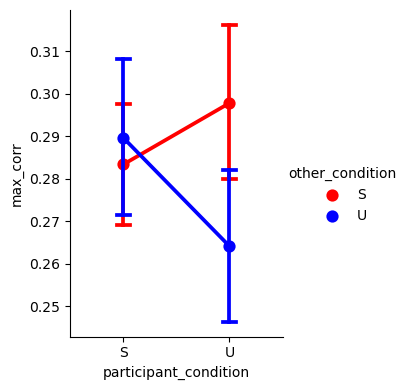

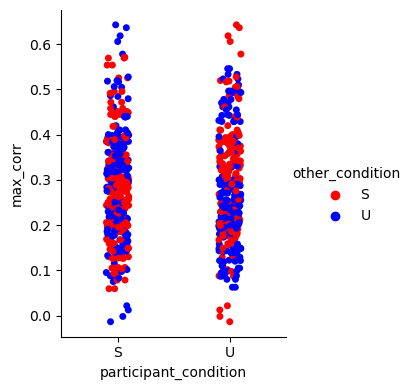

In [23]:
df_analysis = mi_df.copy()
#df_analysis = mi_df.loc[mi_df["participant_manipulated"] == False]
#df_analysis = df_analysis.loc[df_analysis["other_manipulated"] == False]

sns.catplot(x="participant_condition"
            , hue="other_condition"
            , y="max_corr"
            , data=df_analysis
            , kind="point"
            , palette=sns.color_palette(['red', 'blue'])
            , order=["S", "U"]
            , hue_order= ["S", "U"]
            , capsize=0.12
            , aspect=0.8
            , height=4
            )
sns.catplot(x="participant_condition"
            , hue="other_condition"
            , y="max_corr"
            , data=df_analysis
            , palette=sns.color_palette(['red', 'blue'])
            , order=["S", "U"]
            , hue_order= ["S", "U"]
            , aspect=0.8
            , height=4
            )

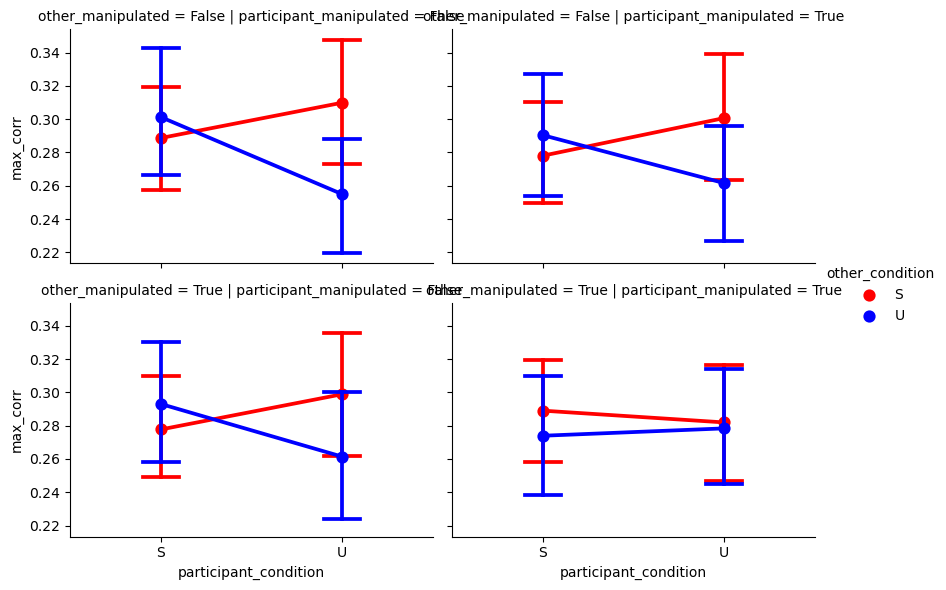

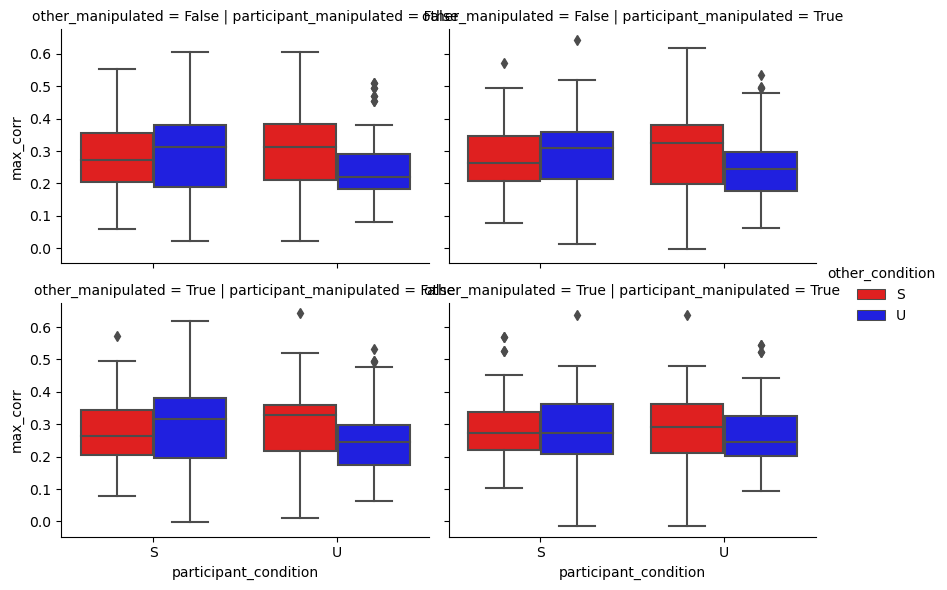

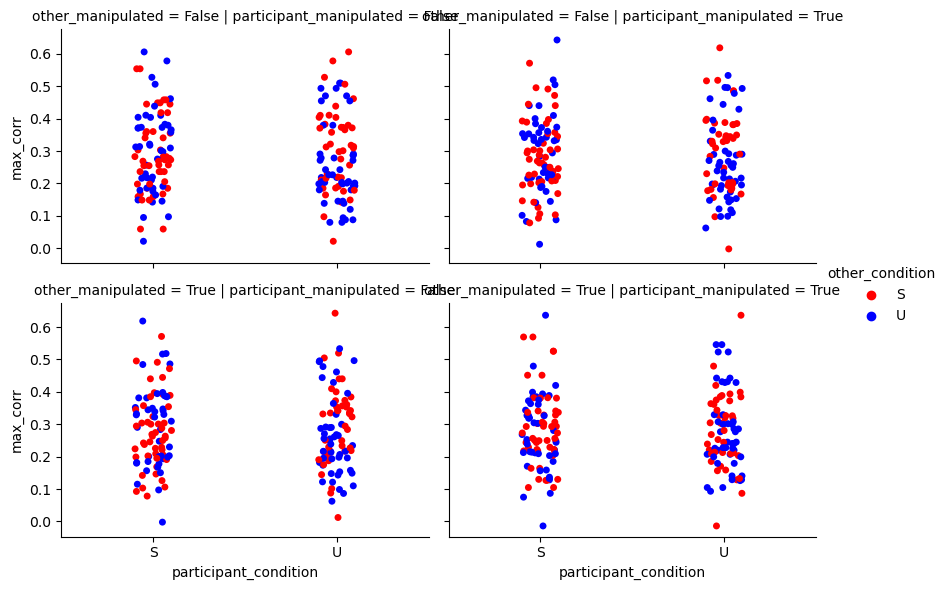

In [24]:
sns.catplot(x="participant_condition"
            , hue="other_condition"
            , y="max_corr"
            , col="participant_manipulated"
            , row="other_manipulated"
            , data=mi_df
            , palette=sns.color_palette(['red', 'blue'])
            , hue_order=["S", "U"]
            , order=["S", "U"]
            , kind="point"
            , aspect=1.4
            , height=3
            , capsize=0.2
            )

sns.catplot(x="participant_condition"
            , hue="other_condition"
            , y="max_corr"
            , col="participant_manipulated"
            , row="other_manipulated"
            , data=mi_df
            , kind="box"
            , palette=sns.color_palette(['red', 'blue'])
            , hue_order=["S", "U"]
            , order=["S", "U"]
            , aspect=1.4
            , height=3
            )
sns.catplot(x="participant_condition"
            , hue="other_condition"
            , col="participant_manipulated"
            , row="other_manipulated"
            , y="max_corr"
            , data=mi_df
            , palette=sns.color_palette(['red', 'blue'])
            , hue_order=["S", "U"]
            , order=["S", "U"]
            , aspect=1.4
            , height=3
            )

## Lags

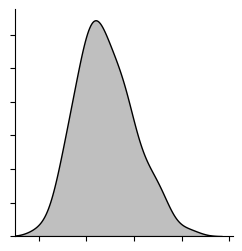

In [15]:
df_analysis = mi_df.groupby("u_dyad").mean(numeric_only=True)

g = sns.displot(df_analysis, x="max_corr", kind="kde", fill=True, aspect=1, height=3, color="black")

plt.xlim(-0.1, None)

plt.savefig("plots/max_corr_dist_legend.pdf",bbox_inches='tight')
g.set(yticklabels=[], xticklabels=[], title='', xlabel=None, ylabel=None)
plt.savefig("plots/max_corr_dist.pdf",bbox_inches='tight')


In [18]:
import pingouin as pg

# Perform a one-sample t-test with pingouin, including Cohen's d
ttest_results = pg.ttest(df_analysis['max_corr'], 0)

# Print the results
print(ttest_results)

                T  dof alternative         p-val        CI95%   cohen-d  \
T-test  22.666236   92   two-sided  2.005783e-39  [0.25, 0.3]  2.350379   

             BF10  power  
T-test  1.132e+36    1.0  


/Users/arias/opt/anaconda3/envs/stim39/lib/python3.9/site-packages/outdated/utils.py:14: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.3, the latest is 0.5.5.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(


In [17]:
len(df_analysis)

93

/Users/arias/opt/anaconda3/envs/stim39/lib/python3.9/site-packages/seaborn/axisgrid.py:848: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  func(*plot_args, **plot_kwargs)


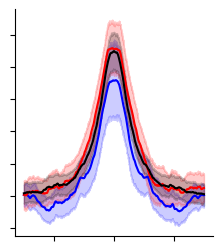

In [25]:
df_lags["u_cond"] = df_lags["participant_condition"] + df_lags["other_condition"]
df_lags["u_dyad"] = df_lags["sid"] + df_lags["dyad"]

df_analysis = df_lags

df_analysis["u_cond"] = [x.replace("US", "SU") for x in df_analysis["u_cond"].values]

#df_analysis = df_analysis.loc[df_analysis["u_cond"] != "US"]
#df_analysis = df_analysis.loc[df_analysis["u_cond"] != "SU"]

#df_analysis = df_analysis.loc[df_analysis["participant_manipulated"] == False]
#df_analysis = df_analysis.loc[df_analysis["other_manipulated"] == False]

#df_analysis = df_analysis.groupby(["lag", "user_id", "participant_condition", "other_condition", "u_cond"]).mean(numeric_only=True).reset_index()

df_analysis = df_analysis.groupby(["lag", "u_dyad", "participant_condition", "other_condition", "u_cond"]).mean(numeric_only=True).reset_index()


g = sns.relplot(x="lag", y="corr"
            , aspect=1
            , height=3
            , hue="u_cond"
            , data= df_analysis
            , kind="line"
            , ci=95
            , hue_order = ["UU", "SS", "SU"]
            , palette= ["blue", "red" , "black"]
            , legend=False
            )

plt.savefig("plots/pf_synch_legend.pdf", bbox_inches='tight')
g.set(xticklabels=[], yticklabels=[], title='',xlabel=None, ylabel=None)
plt.savefig("plots/pf_synch_no_leg.pdf", bbox_inches='tight')

/Users/arias/opt/anaconda3/envs/stim39/lib/python3.9/site-packages/seaborn/axisgrid.py:848: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 68)` for the same effect.

  func(*plot_args, **plot_kwargs)
/Users/arias/opt/anaconda3/envs/stim39/lib/python3.9/site-packages/seaborn/axisgrid.py:848: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 68)` for the same effect.

  func(*plot_args, **plot_kwargs)


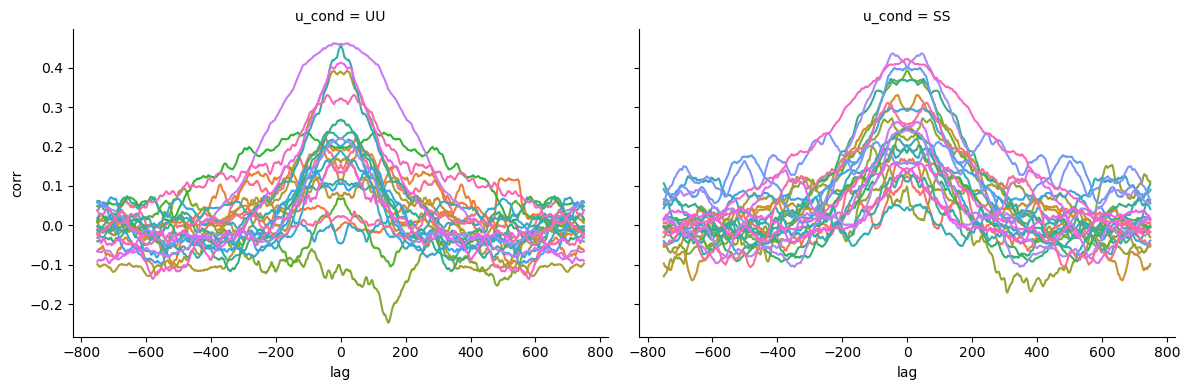

In [68]:
df_lags["u_cond"] = df_lags["participant_condition"] + df_lags["other_condition"]
df_lags["u_dyad"] = df_lags["sid"] + df_lags["dyad"]

df_analysis = df_lags

df_analysis = df_analysis.loc[df_analysis["u_cond"] != "US"]
df_analysis = df_analysis.loc[df_analysis["u_cond"] != "SU"]

df_analysis = df_analysis.loc[df_analysis["participant_manipulated"] == False]
df_analysis = df_analysis.loc[df_analysis["other_manipulated"] == False]

df_analysis = df_analysis.groupby(["lag", "u_dyad", "participant_condition", "other_condition", "u_cond"]).mean(numeric_only=True).reset_index()

sns.relplot(x="lag", y="corr", height=4,aspect=1.5, col="u_cond", data= df_analysis, kind="line", ci=68, hue="u_dyad", legend=False)

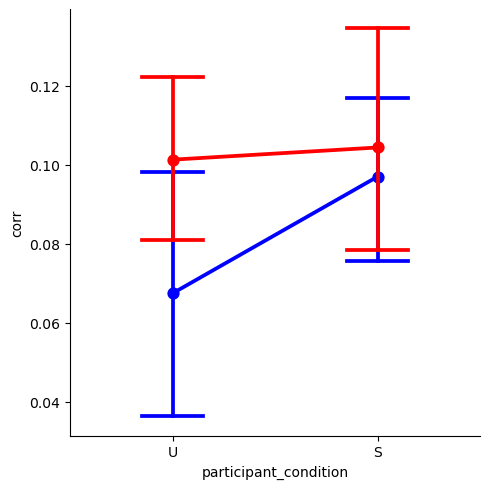

In [28]:
df_lags["u_cond"] = df_lags["participant_condition"] + df_lags["other_condition"]
df_lags["u_dyad"] = df_lags["sid"] + df_lags["dyad"]

df_analysis = df_lags

df_analysis = df_analysis.loc[df_analysis["lag"] > -400]
df_analysis = df_analysis.loc[df_analysis["lag"] < 400]

#df_analysis = df_analysis.loc[df_analysis["u_cond"] != "US"]
#df_analysis = df_analysis.loc[df_analysis["u_cond"] != "SU"]

df_analysis = df_analysis.loc[df_analysis["participant_manipulated"] == False]
df_analysis = df_analysis.loc[df_analysis["other_manipulated"] == False]

#df_analysis = df_analysis.groupby(["lag", "user_id", "participant_condition", "other_condition", "u_cond"]).mean(numeric_only=True).reset_index()

df_analysis = df_analysis.groupby(["u_dyad", "participant_condition", "other_condition", "u_cond"]).mean(numeric_only=True).reset_index()


g = sns.catplot( y="corr"
            , x = "participant_condition"
            , hue = "other_condition"
            , data= df_analysis
            , palette= ["blue", "red" ]
            , legend=False
            , kind="point"
            , capsize=0.3
            )


So, seems to be an effect of synchrony.

## Cluster permutation test

In [69]:
#import data
df_lags = pd.read_csv("data/pyf_results/df_lags.csv")
df_lags["u_cond"] = df_lags["participant_condition"] + df_lags["other_condition"]
df_lags["u_dyad"] = df_lags["sid"] + df_lags["dyad"]

In [76]:
#Random subsampling of the data to get as many observations per condition
#Cluster permutation test with mne

#Prepare data
df_analysis = df_lags.copy()
df_analysis = df_analysis.loc[df_analysis["participant_manipulated"] == False]
df_analysis = df_analysis.loc[df_analysis["other_manipulated"] == False]
df_analysis = df_analysis.groupby(["lag", "u_dyad", "participant_condition", "other_condition", "u_cond"]).mean(numeric_only=True).reset_index().copy()
df_analysis.sort_values(by=["u_cond", "u_dyad", "lag"], inplace=True)

# Exclude conditions
df_analysis = df_analysis.loc[~df_analysis["u_cond"].isin(["US", "SU"])]

# Get conditions
conditions = df_analysis['u_cond'].unique()

# Determine the minimum number of dyads across all conditions
min_dyads = df_analysis.groupby('u_cond')['u_dyad'].nunique().min()

# Subsample each condition to have min_dyads observations
subsampling = pd.DataFrame()  # Initialize an empty DataFrame to store subsampled data

for cond in conditions:
    cond_data = df_analysis[df_analysis['u_cond'] == cond]
    
    # Randomly sample dyads within this condition
    sampled_dyads = np.random.choice(cond_data['u_dyad'].unique(), size=min_dyads, replace=False)
    
    # Filter the condition data to only include the sampled dyads
    subsampled_data = cond_data[cond_data['u_dyad'].isin(sampled_dyads)]
    
    # Append to the subsampling DataFrame
    subsampling = pd.concat([subsampling, subsampled_data])

# Now subsampling contains the balanced dataset
# Next, prepare the data array with this balanced dataset

# Reset df_analysis to the subsampled data
df_analysis = subsampling.copy()

# Re-initialize to match subsampled data dimensions
data = np.empty((len(conditions), min_dyads, len(df_analysis['lag'].unique())))
print("The subsampled data has the following dimensions : " + str(data.shape))

# Fill the data array with subsampled data
for i, cond in enumerate(conditions):
    dyads = df_analysis[df_analysis['u_cond'] == cond]['u_dyad'].unique()
    for j, dyad in enumerate(dyads):
        condition_dyad_data = df_analysis[(df_analysis['u_cond'] == cond) & (df_analysis['u_dyad'] == dyad)]
        # Ensure the time series data is complete and in order
        data[i, j, :] = condition_dyad_data.set_index('lag').reindex(df_analysis['lag'].unique())["corr"].ffill().bfill().values.squeeze()

# Proceed with the cluster-based permutation test using this balanced data array
# Perform the cluster-based permutation test
# We'll assume two conditions for simplicity
cluster_stats = mne.stats.permutation_cluster_test(
    [data[0], data[1]],  # Comparing the first two conditions
    n_permutations=5000,
    threshold=None,
    tail=0,
    out_type='mask'
)

T_obs, clusters, cluster_p_values, H0 = cluster_stats
print("cluster_p_values ", cluster_p_values)

# Identify significant clusters
good_cluster_inds = np.where(cluster_p_values < 0.05)[0]

print("Significant clusters:", good_cluster_inds)
print("Cluster p-values:", cluster_p_values[good_cluster_inds])

The subsampled data has the following dimensions : (2, 24, 1500)
Using a threshold of 4.051749
stat_fun(H1): min=0.000005 max=5.760509
Running initial clustering …
Found 6 clusters


/var/folders/g5/mqbcmmn575z0s3c021r942c80000gp/T/ipykernel_68222/3015320921.py:56: RuntimeWarning: Ignoring argument "tail", performing 1-tailed F-test
  cluster_stats = mne.stats.permutation_cluster_test(


  0%|          | Permuting : 0/4999 [00:00<?,       ?it/s]

cluster_p_values  [0.2704 0.448  0.441  0.317  0.3708 0.2824]
Significant clusters: []
Cluster p-values: []


## Comparing to 0

In [71]:
#Cluster permutation test with mne
import mne

n_permutations = 5000
min_lag = np.min(df_lags["lag"])

#Prepare data
df_analysis = df_lags.copy()
df_analysis = df_analysis.loc[df_analysis["participant_manipulated"] == False]
df_analysis = df_analysis.loc[df_analysis["other_manipulated"] == False]
df_analysis = df_analysis.groupby(["lag", "u_dyad", "participant_condition", "other_condition", "u_cond"]).mean(numeric_only=True).reset_index().copy()

df_analysis.sort_values(by=["u_cond", "u_dyad", "lag"], inplace=True)

#Exlucde conditions
df_analysis = df_analysis.loc[df_analysis["u_cond"] != "US"]
df_analysis = df_analysis.loc[df_analysis["u_cond"] != "SU"]

conditions = df_analysis['u_cond'].unique()

for cond, df in df_analysis.groupby(["u_cond"]):
    dyads = df['u_dyad'].unique()
    lags = df['lag'].unique()

    # Prepare a list to hold the data for each condition
    # Each element of the list is an array of shape (n_dyads, n_timepoints)
    data_by_condition = []
    significant_clusters_info = []
    # Initialize an array for this condition
    condition_data = np.empty((len(dyads), len(lags)))
    
    for j, dyad in enumerate(dyads):
        condition_dyad_data = df[(df['u_cond'] == cond) & (df['u_dyad'] == dyad)]
        # Ensure the time series data is complete and in order
        condition_data[j, :] = condition_dyad_data.set_index('lag')["corr"].reindex(lags).ffill().bfill().values.squeeze()
    
    print("This condition has the following dimensions : " + str(condition_data.shape))

    #Step 2: Run the Cluster-based Permutation Test for Each Condition
    # Run the cluster-based permutation test for each condition
    cluster_stats = mne.stats.permutation_cluster_1samp_test(
        condition_data,
        n_permutations=n_permutations,
        threshold=None,
        tail=0,  # Two-tailed test
        out_type='mask',
        verbose=True
    )
    
    T_obs, clusters, cluster_p_values, H0 = cluster_stats
    
    # Identify significant clusters
    good_cluster_inds = np.where(cluster_p_values < 0.05)[0]
    
    print(f"Condition {cond}")
    print("Significant clusters:", good_cluster_inds)
    print("Cluster p-values:", cluster_p_values[good_cluster_inds])
    print("Cluster lag range :", clusters[0][0].start + min_lag, " -- ", clusters[0][0].stop + min_lag)
    
    significant_clusters_info.append({
        "condition": cond,
        "significant_clusters": good_cluster_inds,
        "p_values": cluster_p_values[good_cluster_inds],
    })


This condition has the following dimensions : (25, 1500)
Using a threshold of 2.063899
stat_fun(H1): min=-0.360858 max=10.891455
Running initial clustering …
Found 1 cluster


/var/folders/g5/mqbcmmn575z0s3c021r942c80000gp/T/ipykernel_68222/2760421937.py:21: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  for cond, df in df_analysis.groupby(["u_cond"]):


  0%|          | Permuting : 0/4999 [00:00<?,       ?it/s]

Condition SS
Significant clusters: [0]
Cluster p-values: [0.0002]
Cluster lag range : -327  --  292
This condition has the following dimensions : (24, 1500)
Using a threshold of 2.068658
stat_fun(H1): min=-3.048633 max=6.369943
Running initial clustering …
Found 5 clusters


  0%|          | Permuting : 0/4999 [00:00<?,       ?it/s]

Condition UU
Significant clusters: [0]
Cluster p-values: [0.0028]
Cluster lag range : -211  --  203


## Correlations : Synchrony and behavior

In [92]:
#import data
mi_df = pd.read_csv("data/pyf_results/mi_df.csv")
mi_df["u_cond"] = mi_df["participant_condition"] + mi_df["other_condition"]
mi_df["u_dyad"] = mi_df["sid"] + mi_df["dyad"]

mi_df = mi_df.groupby(["u_cond", "u_dyad"]).mean()

/var/folders/g5/mqbcmmn575z0s3c021r942c80000gp/T/ipykernel_66651/2007714816.py:6: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  mi_df = mi_df.groupby(["u_cond", "u_dyad"]).mean()


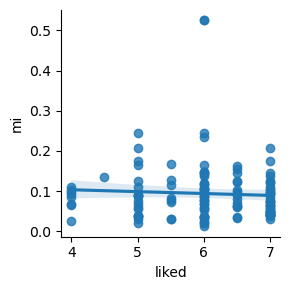

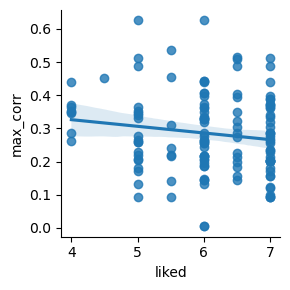

In [93]:
sns.lmplot(y="mi", x="liked",data=mi_df, height=3)
sns.lmplot(y="max_corr", x="liked",data=mi_df, height=3)

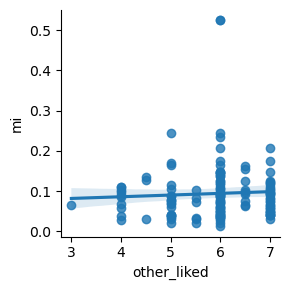

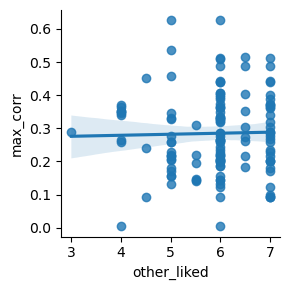

In [94]:

sns.lmplot(y="mi", x="other_liked",data=mi_df, height=3)
sns.lmplot(y="max_corr", x="other_liked",data=mi_df, height=3)

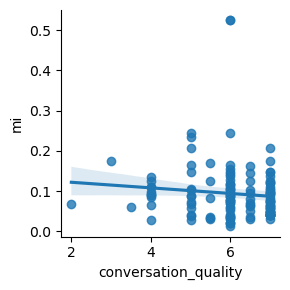

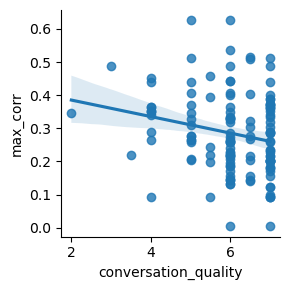

In [95]:
sns.lmplot(y="mi", x="conversation_quality",data=mi_df, height=3)
sns.lmplot(y="max_corr", x="conversation_quality",data=mi_df, height=3)

In [97]:
from scipy import stats
from scipy.stats import spearmanr

for col in ["max_corr", "mi"]:
    print("")    
    print(col +  " RESULTS -------------")
    for measure in ["liked", "other_liked", "conversation_quality", "video_conf_quality"]:
        x = mi_df[col].values
        y = mi_df[measure].values

        pr, pp = stats.pearsonr(x, y)
        sr, sp = correlation, p_value = spearmanr(x, y)

        
        print(measure)
        print( "Pearson: R : "+ str(pr), "p= " + str(pp))
        print( "Spearman: R : "+ str(sr), "p= " + str(sp))
        print()
        


max_corr RESULTS -------------
liked
Pearson: R : -0.14728097263219214 p= 0.08826036796300568
Spearman: R : -0.1290926402593492 p= 0.1356402924234829

other_liked
Pearson: R : 0.023829391563433815 p= 0.7838257696527702
Spearman: R : 0.04856081594076057 p= 0.5759507670635666

conversation_quality
Pearson: R : -0.21584735758165718 p= 0.011926526308195639
Spearman: R : -0.1986247330583225 p= 0.020920820866476942

video_conf_quality
Pearson: R : 0.06904939034156946 p= 0.42616489237554206
Spearman: R : 0.0818170532501652 p= 0.34549107517083943


mi RESULTS -------------
liked
Pearson: R : -0.05761160536715295 p= 0.5068737914308774
Spearman: R : -0.07376443506899226 p= 0.39518354963731794

other_liked
Pearson: R : 0.05414481225493119 p= 0.5328156763044194
Spearman: R : 0.09565807999545721 p= 0.2697475146698895

conversation_quality
Pearson: R : -0.10069130981356285 p= 0.24523381109340664
Spearman: R : -0.12612361866281352 p= 0.14494407287930994

video_conf_quality
Pearson: R : -0.1642139130